In [7]:
from pathlib import Path
print("CWD:", Path(".").resolve())

checks = [
  "data/raw/provinces_shp/zaf_admbnda_adm1_sadb_ocha_20201109.shp",
  "data/raw/zaf_adm_sadb_ocha_20201109_shp/zaf_adm_sadb_ocha_20201109_SHP/zaf_admbnda_adm1_sadb_ocha_20201109.shp",
  "data/raw/zaf_adm_sadb_ocha_20201109_shp.zip",
]
for s in checks:
    p = Path(s)
    print(f"{s} -> exists={p.exists()} size={p.stat().st_size if p.exists() else None}")


CWD: /workspace/notebooks
data/raw/provinces_shp/zaf_admbnda_adm1_sadb_ocha_20201109.shp -> exists=False size=None
data/raw/zaf_adm_sadb_ocha_20201109_shp/zaf_adm_sadb_ocha_20201109_SHP/zaf_admbnda_adm1_sadb_ocha_20201109.shp -> exists=False size=None
data/raw/zaf_adm_sadb_ocha_20201109_shp.zip -> exists=False size=None


In [9]:
from pathlib import Path
import geopandas as gpd

# 1) Resolve project ROOT no matter where the notebook sits
ROOT = Path("/workspace") if Path("/workspace/data").exists() else Path.cwd().parents[0]
RAW  = ROOT / "data" / "raw"
print("ROOT:", ROOT)
print("RAW exists:", RAW.exists())

# 2) Read the staged ADM1 shapefile from the absolute project path
shp = RAW / "provinces_shp" / "zaf_admbnda_adm1_sadb_ocha_20201109.shp"
print("Shapefile path:", shp, "exists:", shp.exists())

gdf = gpd.read_file(shp, engine="fiona").to_crs(4326)

# 3) Pick the province name column & write GeoJSON
for cand in ["ADM1_EN", "NAME_1", "PROVINCE", "Province", "NAME"]:
    if cand in gdf.columns: name_col = cand; break

gdf = gdf.rename(columns={name_col: "province"})[["province","geometry"]]
gdf["province"] = (
    gdf["province"].astype(str).str.strip()
      .replace({"Kwazulu-Natal":"KwaZulu-Natal","North West Province":"North West"})
)

out = RAW / "provinces.geojson"
gdf.to_file(out, driver="GeoJSON")
print("Wrote:", out)
sorted(gdf["province"].unique())


ROOT: /workspace
RAW exists: True
Shapefile path: /workspace/data/raw/provinces_shp/zaf_admbnda_adm1_sadb_ocha_20201109.shp exists: True
Wrote: /workspace/data/raw/provinces.geojson


['Eastern Cape',
 'Free State',
 'Gauteng',
 'KwaZulu-Natal',
 'Limpopo',
 'Mpumalanga',
 'North West',
 'Nothern Cape',
 'Western Cape']

In [10]:
from pathlib import Path
import geopandas as gpd

RAW = Path("/workspace/data/raw")
geo = RAW / "provinces.geojson"

gdf = gpd.read_file(geo)
gdf["province"] = (
    gdf["province"]
      .astype(str)
      .str.strip()
      .replace({"Nothern Cape": "Northern Cape", "Kwazulu-Natal": "KwaZulu-Natal"})
)

gdf.to_file(geo, driver="GeoJSON")
print("Wrote:", geo)
print(sorted(gdf["province"].unique()))


Wrote: /workspace/data/raw/provinces.geojson
['Eastern Cape', 'Free State', 'Gauteng', 'KwaZulu-Natal', 'Limpopo', 'Mpumalanga', 'North West', 'Northern Cape', 'Western Cape']


In [15]:
from pathlib import Path
import sys, pandas as pd

# --- paths ---
ROOT = Path("/workspace")
RAW  = ROOT / "data" / "raw"
OUT  = ROOT / "outputs" / "tables"
SRC  = ROOT / "src"
OUT.mkdir(parents=True, exist_ok=True)

# --- load helpers (create if missing) ---
SRC.mkdir(parents=True, exist_ok=True)
util_path = SRC / "utils.py"
if not util_path.exists():
    util_path.write_text(
        """from dataclasses import dataclass
import pandas as pd

@dataclass
class MismatchParams:
    threshold_pct: float = 20.0

def compute_mismatch(df: pd.DataFrame, params: MismatchParams = MismatchParams()) -> pd.DataFrame:
    out = df.copy()
    out["resistance_pct"] = pd.to_numeric(out["resistance_pct"], errors="coerce")
    out["mismatch_index"] = (out["resistance_pct"] - float(params.threshold_pct)).clip(lower=0)
    out["flag"] = (out["mismatch_index"] > 0).map({True: "review", False: "ok"})
    return out

def top_n_mismatches(df: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    return df.sort_values("mismatch_index", ascending=False).head(n).reset_index(drop=True)
"""
    )
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from utils import compute_mismatch, MismatchParams

# --- robust NICD loader for your two exports ---
def load_nicd_table(path: Path, organism: str, antibiotic_for_amr: str, year=2022, sector="Public") -> pd.DataFrame:
    df = pd.read_csv(path)
    cols_l = {c.lower(): c for c in df.columns}

    # province column
    prov = next((cols_l[k] for k in cols_l if "province" in k), None)
    if prov is None:
        raise ValueError(f"Can't find province column in {path.name}: {df.columns.tolist()}")

    # R (%) column
    r_candidates = [c for c in df.columns if "R" in c and "%" in c]
    if not r_candidates:
        # fallbacks for odd headers
        r_candidates = [c for c in df.columns if c.strip().lower() in ("r(%)","r %","r (%)","r%")]
    if not r_candidates:
        raise ValueError(f"Can't find R(%) column in {path.name}: {df.columns.tolist()}")
    rcol = r_candidates[0]

    # total tested
    n_candidates = [c for c in df.columns if "Total" in c and "Tested" in c]
    if not n_candidates:
        n_candidates = [cols_l[k] for k in cols_l if "total" in k and "tested" in k]
    if not n_candidates:
        raise ValueError(f"Can't find Total Tested column in {path.name}: {df.columns.tolist()}")
    ncol = n_candidates[0]

    out = (
        df.rename(columns={prov: "province", rcol: "percent_resistant", ncol: "n_tested"})
          [["province","percent_resistant","n_tested"]]
          .copy()
    )
    out["percent_resistant"] = (
        out["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
    ).astype(float)

    # normalize province names (just in case)
    fixes = {"Kwazulu-Natal": "KwaZulu-Natal", "North West Province": "North West"}
    out["province"] = out["province"].astype(str).str.strip().replace(fixes)

    out["organism"]  = organism
    out["antibiotic"] = antibiotic_for_amr
    out["year"] = year
    out["sector"] = sector
    return out

# your two files (second is CEFOXITIN -> store as 'methicillin' proxy)
ecoli_path = RAW / "nicd_ecoli_ciprofloxacin_2022_public.csv"
saureus_path = RAW / "nicd_saureus_CEFOXITIN_2022_public.csv"

ecoli   = load_nicd_table(ecoli_path,   "Escherichia coli",       "ciprofloxacin")
saureus = load_nicd_table(saureus_path, "Staphylococcus aureus",  "methicillin")

nicd = pd.concat([ecoli, saureus], ignore_index=True)
nicd.to_csv(RAW / "amr_rates_nicd.csv", index=False)
print("Wrote:", RAW / "amr_rates_nicd.csv")

# --- join to pairs + STG and compute mismatch ---
stg   = pd.read_csv(RAW / "stg_firstline.csv")
pairs = pd.read_csv(RAW / "amr_pairs.csv")

amr_j = nicd.merge(pairs, left_on=["organism","antibiotic"],
                   right_on=["organism","antibiotic_for_amr"], how="inner")

df = amr_j.merge(stg[["syndrome","organism","first_line_antibiotic"]],
                 on=["syndrome","organism"], how="left")

mismatch = compute_mismatch(
    df.rename(columns={"percent_resistant":"resistance_pct"})[
        ["province","syndrome","first_line_antibiotic","resistance_pct"]
    ],
    MismatchParams(threshold_pct=20.0)
)

out_csv = OUT / "mismatch_index.csv"
mismatch.to_csv(out_csv, index=False)
print("Wrote:", out_csv)

mismatch.sort_values(["syndrome","mismatch_index"], ascending=[True, False]).head(12)


Wrote: /workspace/data/raw/amr_rates_nicd.csv
Wrote: /workspace/outputs/tables/mismatch_index.csv


,province,syndrome,first_line_antibiotic,resistance_pct,mismatch_index,flag
17,WESTERN CAPE,Cellulitis_SSTI,cefalexin | flucloxacillin,100.0,80.0,review
9,FREE STATE,Cellulitis_SSTI,cefalexin | flucloxacillin,39.0,19.0,review
12,KWAZULU-NATAL,Cellulitis_SSTI,cefalexin | flucloxacillin,33.0,13.0,review
11,GAUTENG,Cellulitis_SSTI,cefalexin | flucloxacillin,11.0,0.0,ok
10,EASTERN CAPE,Cellulitis_SSTI,cefalexin | flucloxacillin,NaN,NaN,ok
13,MPUMALANGA,Cellulitis_SSTI,cefalexin | flucloxacillin,NaN,NaN,ok
14,LIMPOPO,Cellulitis_SSTI,cefalexin | flucloxacillin,NaN,NaN,ok
15,NORTH WEST,Cellulitis_SSTI,cefalexin | flucloxacillin,NaN,NaN,ok
16,NORTHERN CAPE,Cellulitis_SSTI,cefalexin | flucloxacillin,NaN,NaN,ok
3,KWAZULU-NATAL,UTI_uncomplicated,nitrofurantoin,46.0,26.0,review


Saved: /workspace/outputs/figures/mismatch_heatmap_Cellulitis_SSTI.png


,province,resistance_pct,mismatch_index,status
0,Eastern Cape,NaN,NaN,no_data
1,Limpopo,NaN,NaN,no_data
2,Mpumalanga,NaN,NaN,no_data
3,North West,NaN,NaN,no_data
4,Northern Cape,NaN,NaN,no_data
5,Gauteng,11.0,0.0,ok
6,Western Cape,100.0,80.0,review
7,Free State,39.0,19.0,review
8,KwaZulu-Natal,33.0,13.0,review


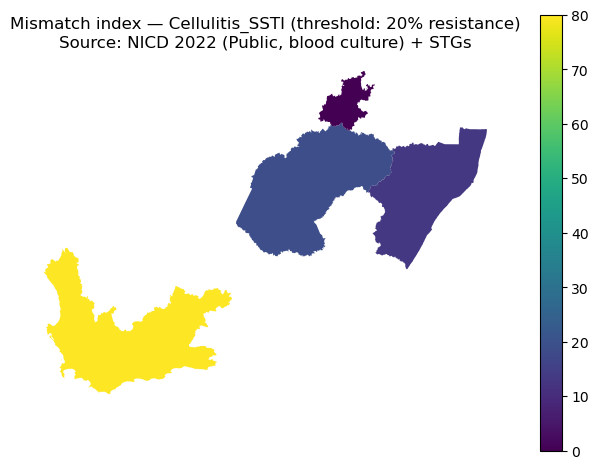

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path("/workspace")
RAW  = ROOT / "data" / "raw"
OUTF = ROOT / "outputs" / "figures"
OUTF.mkdir(parents=True, exist_ok=True)

# Load map + mismatch table
provinces = gpd.read_file(RAW / "provinces.geojson")
mismatch  = pd.read_csv(ROOT / "outputs" / "tables" / "mismatch_index.csv")

# Normalize province names consistently
def norm_prov(x: str) -> str:
    x = str(x).strip().title()
    x = x.replace("Kwazulu-Natal", "KwaZulu-Natal").replace("Nothern", "Northern")
    return x

provinces["province"] = provinces["province"].map(norm_prov)
mismatch["province"]  = mismatch["province"].map(norm_prov)

# Choose one syndrome to visualize first
syn = "Cellulitis_SSTI"   # change to "UTI_uncomplicated" to view UTI
sub = mismatch[mismatch["syndrome"] == syn].copy()

# Merge for map
g = provinces.merge(sub, on="province", how="left")

# Status labels for context
g["status"] = np.where(
    g["resistance_pct"].isna(), "no_data",
    np.where(g["mismatch_index"] > 0, "review", "ok")
)

# Plot
ax = g.plot(column="mismatch_index", legend=True)
ax.set_axis_off()
ax.set_title(f"Mismatch index — {syn} (threshold: 20% resistance)\nSource: NICD 2022 (Public, blood culture) + STGs")
plt.tight_layout()
fig_path = OUTF / f"mismatch_heatmap_{syn}.png"
plt.savefig(fig_path, dpi=150)
print("Saved:", fig_path)

# Preview table for this syndrome
display(
    g[["province","resistance_pct","mismatch_index","status"]]
    .sort_values(["status","mismatch_index"], ascending=[True, False])
    .reset_index(drop=True)
)


In [17]:
from pathlib import Path
import pandas as pd

RAW = Path("/workspace/data/raw")

sa_path = RAW / "nicd_saureus_CEFOXITIN_2022_public.csv"
df = pd.read_csv(sa_path)

print("COLUMNS:", list(df.columns))
print("\nRAW ROW FOR WESTERN CAPE:")
prov_col = [c for c in df.columns if c.strip().lower().startswith("province")][0]
print(df.loc[df[prov_col].str.contains("western", case=False, na=False)])

# robust selector for the exact R(%) and Total Tested columns
def pick_cols(d):
    cols = list(d.columns)
    # province
    prov = [c for c in cols if c.strip().lower().startswith("province")][0]
    # R (%): prefer an exact-looking name, then fallbacks
    pref = [c for c in cols if c.strip().lower() in {"r(%)","r (%)","r%","r %"}]
    if pref:
        rcol = pref[0]
    else:
        rcol = [c for c in cols if "R" in c and "%" in c][0]  # only if exact not found
    # total tested
    ncol = [c for c in cols if "total" in c.lower() and "tested" in c.lower()][0]
    return prov, rcol, ncol

prov, rcol, ncol = pick_cols(df)
print("\nUSING COLUMNS:", {"province": prov, "R(%)": rcol, "Total Tested": ncol})

fixed = (df.rename(columns={prov:"province", rcol:"percent_resistant", ncol:"n_tested"})
           [["province","percent_resistant","n_tested"]].copy())

fixed["percent_resistant"] = (
    fixed["percent_resistant"].astype(str).str.replace("%","", regex=False).str.strip()
).astype(float)

print("\nCHECK VALUES AFTER CLEANING (S. aureus MRSA):")
print(fixed.sort_values("province"))


COLUMNS: ['Province', 'S', 'S (%)', 'SDD', 'SDD (%)', 'I', 'I (%)', 'R', 'R (%)', 'Total Tested', 'Not Tested']

RAW ROW FOR WESTERN CAPE:
       Province   S S (%)  SDD  SDD (%)   I  I (%)    R R (%)  Total Tested  \
8  WESTERN CAPE NaN   NaN  NaN      NaN NaN    NaN  2.0  100%             2   

   Not Tested  
8        1647  

USING COLUMNS: {'province': 'Province', 'R(%)': 'R (%)', 'Total Tested': 'Total Tested'}

CHECK VALUES AFTER CLEANING (S. aureus MRSA):
        province  percent_resistant  n_tested
1   EASTERN CAPE                NaN         3
0     FREE STATE               39.0        46
2        GAUTENG               11.0       416
3  KWAZULU-NATAL               33.0         6
5        LIMPOPO                NaN         4
4     MPUMALANGA                NaN        34
6     NORTH WEST                NaN        19
7  NORTHERN CAPE                NaN         2
8   WESTERN CAPE              100.0         2


Wrote: /workspace/outputs/tables/mismatch_index.csv
Saved: /workspace/outputs/figures/mismatch_heatmap_Cellulitis_SSTI_nmin30.png


,province,n_tested,resistance_pct,mismatch_index,status
0,Eastern Cape,3,NaN,NaN,low_n
1,KwaZulu-Natal,6,NaN,NaN,low_n
2,Limpopo,4,NaN,NaN,low_n
3,North West,19,NaN,NaN,low_n
4,Northern Cape,2,NaN,NaN,low_n
5,Western Cape,2,NaN,NaN,low_n
6,Gauteng,416,11.0,0.0,ok
7,Mpumalanga,34,NaN,NaN,ok
8,Free State,46,39.0,19.0,review


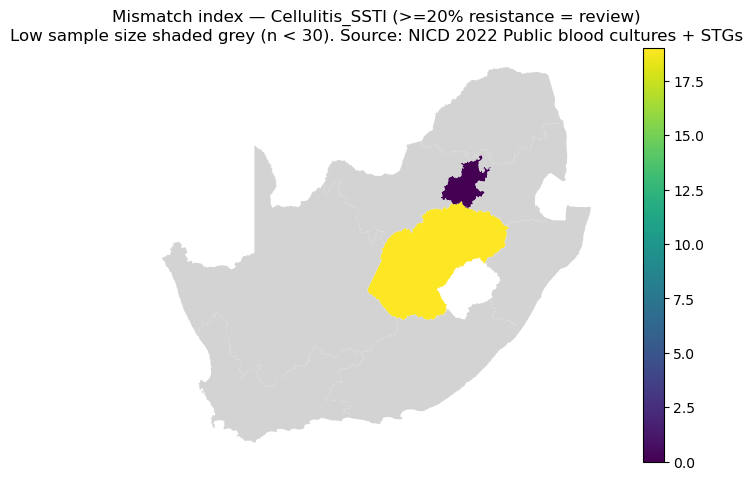

In [18]:
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import sys

# paths
ROOT = Path("/workspace")
RAW  = ROOT / "data" / "raw"
OUTT = ROOT / "outputs" / "tables"
OUTF = ROOT / "outputs" / "figures"
OUTT.mkdir(parents=True, exist_ok=True)
OUTF.mkdir(parents=True, exist_ok=True)

# import helpers
sys.path.insert(0, str(ROOT / "src"))
from utils import compute_mismatch, MismatchParams

# --- 1) load NICD and apply a minimum sample-size rule ---
N_MIN = 30  # tweak if you want
nicd = pd.read_csv(RAW / "amr_rates_nicd.csv")
nicd["low_n"] = nicd["n_tested"] < N_MIN
nicd_f = nicd.copy()
nicd_f.loc[nicd_f["low_n"], "percent_resistant"] = np.nan  # blank out low-N cells
nicd_f.to_csv(RAW / "amr_rates_nicd_filtered.csv", index=False)

# --- 2) recompute mismatch ---
stg   = pd.read_csv(RAW / "stg_firstline.csv")
pairs = pd.read_csv(RAW / "amr_pairs.csv")

amr_j = nicd_f.merge(pairs, left_on=["organism","antibiotic"],
                     right_on=["organism","antibiotic_for_amr"], how="inner")
df = amr_j.merge(stg[["syndrome","organism","first_line_antibiotic"]],
                 on=["syndrome","organism"], how="left")

mismatch = compute_mismatch(
    df.rename(columns={"percent_resistant":"resistance_pct"})[
        ["province","syndrome","first_line_antibiotic","resistance_pct","n_tested"]
    ],
    MismatchParams(threshold_pct=20.0)
)

# normalize province names to Title Case for the map merge
def norm_prov(x: str) -> str:
    x = str(x).strip().title()
    x = x.replace("Kwazulu-Natal", "KwaZulu-Natal").replace("Nothern", "Northern")
    return x
mismatch["province"] = mismatch["province"].map(norm_prov)

mismatch_out = OUTT / "mismatch_index.csv"
mismatch.to_csv(mismatch_out, index=False)
print("Wrote:", mismatch_out)

# --- 3) plot Cellulitis map with low-N greyed out ---
provinces = gpd.read_file(RAW / "provinces.geojson")
provinces["province"] = provinces["province"].map(norm_prov)

syn = "Cellulitis_SSTI"
sub = mismatch[mismatch["syndrome"] == syn].copy()
g = provinces.merge(sub, on="province", how="left")

g["status"] = np.select(
    [
        g["n_tested"].isna(),               # no row
        g["n_tested"].notna() & (g["n_tested"] < N_MIN),  # too small
        g["mismatch_index"].gt(0)          # valid + above threshold
    ],
    ["no_data", "low_n", "review"],
    default="ok"
)

ax = g.plot(column="mismatch_index", legend=True, missing_kwds={"color":"lightgrey"})
ax.set_axis_off()
ax.set_title(f"Mismatch index — {syn} (>=20% resistance = review)\n"
             f"Low sample size shaded grey (n < {N_MIN}). Source: NICD 2022 Public blood cultures + STGs")
plt.tight_layout()
fig_path = OUTF / f"mismatch_heatmap_{syn}_nmin{N_MIN}.png"
plt.savefig(fig_path, dpi=150)
print("Saved:", fig_path)

# show tidy table
display(
    g[["province","n_tested","resistance_pct","mismatch_index","status"]]
      .sort_values(["status","mismatch_index"], ascending=[True, False])
      .reset_index(drop=True)
)


Saved: /workspace/outputs/figures/mismatch_heatmap_UTI_uncomplicated_nmin30.png


,province,n_tested,resistance_pct,mismatch_index,status
0,KwaZulu-Natal,1203,46.0,26.0,review
1,Mpumalanga,293,39.0,19.0,review
2,Eastern Cape,722,33.0,13.0,review
3,Free State,331,32.0,12.0,review
4,North West,197,32.0,12.0,review
5,Gauteng,2879,30.0,10.0,review
6,Northern Cape,136,30.0,10.0,review
7,Limpopo,204,29.0,9.0,review
8,Western Cape,1039,29.0,9.0,review


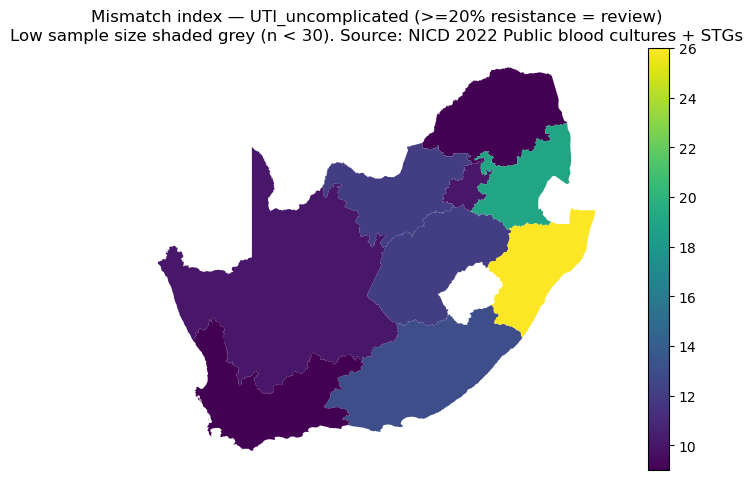

In [19]:
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path("/workspace")
RAW  = ROOT / "data" / "raw"
OUTT = ROOT / "outputs" / "tables"
OUTF = ROOT / "outputs" / "figures"
N_MIN = 30  # keep consistent with previous cell

# load
provinces = gpd.read_file(RAW / "provinces.geojson")
mismatch  = pd.read_csv(OUTT / "mismatch_index.csv")

def norm_prov(x: str) -> str:
    x = str(x).strip().title()
    x = x.replace("Kwazulu-Natal","KwaZulu-Natal").replace("Nothern","Northern")
    return x

provinces["province"] = provinces["province"].map(norm_prov)
mismatch["province"]  = mismatch["province"].map(norm_prov)

# --- UTI ---
syn = "UTI_uncomplicated"   # ciprofloxacin (proxy) vs nitrofurantoin guideline
sub = mismatch[mismatch["syndrome"] == syn].copy()

g = provinces.merge(sub, on="province", how="left")

g["status"] = np.select(
    [
        g["n_tested"].isna(),
        g["n_tested"].notna() & (g["n_tested"] < N_MIN),
        g["mismatch_index"].gt(0)
    ],
    ["no_data","low_n","review"],
    default="ok"
)

ax = g.plot(column="mismatch_index", legend=True, missing_kwds={"color":"lightgrey"})
ax.set_axis_off()
ax.set_title(f"Mismatch index — {syn} (>=20% resistance = review)\n"
             f"Low sample size shaded grey (n < {N_MIN}). Source: NICD 2022 Public blood cultures + STGs")
plt.tight_layout()
fig_path = OUTF / f"mismatch_heatmap_{syn}_nmin{N_MIN}.png"
plt.savefig(fig_path, dpi=150)
print("Saved:", fig_path)

# preview table
display(
    g[["province","n_tested","resistance_pct","mismatch_index","status"]]
      .sort_values(["status","mismatch_index"], ascending=[True, False])
      .reset_index(drop=True)
)


In [23]:
from pathlib import Path
import pandas as pd

ROOT = Path("/workspace")
OUTT = ROOT / "outputs" / "tables"
OUTF = ROOT / "outputs" / "figures"

THRESH = 20.0
N_MIN  = 30

m = pd.read_csv(OUTT / "mismatch_index.csv")

def md_table(df: pd.DataFrame) -> str:
    if df.empty:
        return "_No provinces flagged above threshold._"
    # simple numeric formatting
    def fmt(v):
        if pd.isna(v):
            return ""
        if isinstance(v, (int, float)):
            return f"{float(v):.1f}"
        return str(v)
    cols = list(df.columns)
    lines = [
        "| " + " | ".join(cols) + " |",
        "| " + " | ".join(["---"] * len(cols)) + " |",
    ]
    for _, r in df.iterrows():
        lines.append("| " + " | ".join(fmt(r[c]) for c in cols) + " |")
    return "\n".join(lines)

def top_review(syn):
    sub = m[m["syndrome"] == syn].copy()
    sub = sub[sub["mismatch_index"].fillna(0) > 0]
    sub = sub.sort_values("mismatch_index", ascending=False)
    return sub[["province","resistance_pct","n_tested","mismatch_index"]]\
             .rename(columns={"resistance_pct":"resist_%", "n_tested":"n", "mismatch_index":"excess_%"})

parts = []
for syn in ["Cellulitis_SSTI", "UTI_uncomplicated"]:
    parts.append(f"### {syn}\n")
    parts.append(md_table(top_review(syn)))
    parts.append("\n")

md = f"""# AMR mismatch quicklook (NICD 2022 Public blood cultures vs STGs)

- Threshold for concern: **≥ {THRESH}%** resistant
- Low sample size blanked: **n < {N_MIN}**
- Sources: NICD National AMR Dashboard (2022), SA STGs/EML (PHC 2020; Hospital 2019)

## Heatmaps
![Cellulitis](figures/mismatch_heatmap_Cellulitis_SSTI_nmin{N_MIN}.png)

![UTI uncomplicated](figures/mismatch_heatmap_UTI_uncomplicated_nmin{N_MIN}.png)

## Top flagged provinces
{''.join(parts)}
"""

out_path = ROOT / "outputs" / "summary.md"
out_path.write_text(md)
print("Wrote:", out_path)


Wrote: /workspace/outputs/summary.md
